In [1]:
from pathlib import Path
import sys
import json
import uuid
from datetime import datetime
import os

ROOT_DIR = Path.cwd().parent.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
print(f'Base directory -> {ROOT_DIR}')

from src.db_conn import DatabaseConnection
from config.settings import (
    DATA_DIR,
    MODELS_DIR
)

import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

Base directory -> /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/paramiko/transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


In [2]:
master = pd.read_csv(f'{DATA_DIR}/master.csv')
master['sale_date'] = pd.to_datetime(master['sale_date'])
master = master.set_index('sale_date')
master

,net_price,non_work_day,is_month_end,close_month_zone
sale_date,,,,
2024-01-02,"719,422.63",0,0,0
2024-01-03,"992,292.59",0,0,0
2024-01-04,"802,011.48",0,0,0
2024-01-05,"484,853.02",0,0,0
2024-01-06,"60,058.17",0,0,0
...,...,...,...,...
2026-05-11,"1,790,415.58",0,0,0
2026-05-12,"2,139,962.69",0,0,0
2026-05-13,"1,245,428.49",0,0,1


In [3]:
#generacion de lags
master['lag_1'] = master['net_price'].shift(1)
master['lag_7'] = master['net_price'].shift(7)

#eliminacion de nulos porque los primeros datos no tienen lags
master = master.dropna()

master

,net_price,non_work_day,is_month_end,close_month_zone,lag_1,lag_7
sale_date,,,,,,
2024-01-09,"1,082,699.55",0,0,0,"622,816.98","719,422.63"
2024-01-10,"797,017.78",0,0,0,"1,082,699.55","992,292.59"
2024-01-11,"611,524.10",0,0,0,"797,017.78","802,011.48"
2024-01-12,"826,546.08",0,0,0,"611,524.10","484,853.02"
2024-01-13,0.00,0,0,0,"826,546.08","60,058.17"
...,...,...,...,...,...,...
2026-05-11,"1,790,415.58",0,0,0,0.00,"1,937,861.36"
2026-05-12,"2,139,962.69",0,0,0,"1,790,415.58","1,300,311.08"
2026-05-13,"1,245,428.49",0,0,1,"2,139,962.69","997,436.80"


In [4]:
#definicion de y y X
features = ['lag_1', 'lag_7', 'non_work_day', 'is_month_end', 'close_month_zone']
target = ['net_price']

#definicion de rangos de entreamiento y pruebas
train_cutoff = '2026-03-31'
validation_start = '2026-04-01'
validation_end = '2026-04-30'

In [5]:
#split de datos
X_train_raw = master.loc[:train_cutoff, features]
y_train_raw = master.loc[:train_cutoff, target]

display(X_train_raw)

display(y_train_raw)

,lag_1,lag_7,non_work_day,is_month_end,close_month_zone
sale_date,,,,,
2024-01-09,"622,816.98","719,422.63",0,0,0
2024-01-10,"1,082,699.55","992,292.59",0,0,0
2024-01-11,"797,017.78","802,011.48",0,0,0
2024-01-12,"611,524.10","484,853.02",0,0,0
2024-01-13,"826,546.08","60,058.17",0,0,0
...,...,...,...,...,...
2026-03-27,"1,680,637.42","1,320,038.51",0,0,1
2026-03-28,"1,237,289.26",0.00,0,0,0
2026-03-29,0.00,0.00,0,0,0


,net_price
sale_date,
2024-01-09,"1,082,699.55"
2024-01-10,"797,017.78"
2024-01-11,"611,524.10"
2024-01-12,"826,546.08"
2024-01-13,0.00
...,...
2026-03-27,"1,237,289.26"
2026-03-28,0.00
2026-03-29,0.00


In [ ]:
X_test_raw = master.loc[validation_start:validation_end, features]
y_test_raw = master.loc[validation_start:validation_end, target]

display(X_test_raw)


display(y_test_raw)

,lag_1,lag_7,non_work_day,is_month_end,close_month_zone
sale_date,,,,,
2026-04-01,"2,964,747.97","1,216,806.19",0,0,0
2026-04-02,"1,417,995.00","1,680,637.42",1,0,0
2026-04-03,0.00,"1,237,289.26",1,0,0
2026-04-04,0.00,0.00,0,0,0
2026-04-05,0.00,0.00,0,0,0
2026-04-06,0.00,"2,718,817.07",0,0,0
2026-04-07,"2,877,655.05","2,964,747.97",0,0,0
2026-04-08,"1,780,346.37","1,417,995.00",0,0,0
2026-04-09,"1,674,429.51",0.00,0,0,0


,net_price
sale_date,
2026-04-01,"1,417,995.00"
2026-04-02,0.00
2026-04-03,0.00
2026-04-04,0.00
2026-04-05,0.00
2026-04-06,"2,877,655.05"
2026-04-07,"1,780,346.37"
2026-04-08,"1,674,429.51"
2026-04-09,"1,741,267.80"


In [7]:
#instancia de los escaladores por separados
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_x.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

display(X_train_scaled)

display(y_train_scaled)

array([[0.13442075, 0.15527086, 0.        , 0.        , 0.        ],
       [0.23367585, 0.21416358, 0.        , 0.        , 0.        ],
       [0.172018  , 0.17309577, 0.        , 0.        , 0.        ],
       ...,
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.43090038, 0.        , 0.        , 1.        ],
       [0.58679427, 0.40534182, 0.        , 1.        , 0.        ]],
      shape=(813, 5))

array([[2.33675851e-01],
       [1.72017997e-01],
       [1.31983444e-01],
       [1.78391002e-01],
       [0.00000000e+00],
       [0.00000000e+00],
       [1.86099937e-01],
       [1.99751979e-01],
       [1.84332649e-01],
       [1.22911634e-01],
       [1.33483329e-01],
       [0.00000000e+00],
       [0.00000000e+00],
       [2.18308685e-01],
       [2.10317821e-01],
       [1.75805632e-01],
       [2.08701147e-01],
       [1.04079277e-01],
       [0.00000000e+00],
       [0.00000000e+00],
       [2.92784995e-01],
       [2.21399806e-01],
       [4.34803863e-01],
       [1.24174280e-01],
       [1.00748637e-01],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [2.48617200e-01],
       [1.86357125e-01],
       [1.89492212e-01],
       [1.27533836e-01],
       [4.54052146e-03],
       [0.00000000e+00],
       [1.84615712e-01],
       [3.07193762e-01],
       [1.32138584e-01],
       [1.43301204e-01],
       [1.67832820e-01],
       [0.00000000e+00],


In [8]:
#escalamiento de datos de prueba
X_test_scaled = scaler_x.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

display(X_test_scaled)
display(y_test_scaled)

array([[0.63987281, 0.26261969, 0.        , 0.        , 0.        ],
       [0.30604168, 0.36272702, 1.        , 0.        , 0.        ],
       [0.        , 0.26704049, 1.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.58679427, 0.        , 0.        , 0.        ],
       [0.6210758 , 0.63987281, 0.        , 0.        , 0.        ],
       [0.38424691, 0.30604168, 0.        , 0.        , 0.        ],
       [0.36138718, 0.        , 0.        , 0.        , 0.        ],
       [0.37581269, 0.        , 0.        , 0.        , 0.        ],
       [0.22418103, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.6210758 , 0.        , 0.        , 0.        ],
       [0.39050432, 0.38424691, 0.        , 0.        , 0.        ],
       [0.34256363, 0.36138718, 0.

array([[0.30604168],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.6210758 ],
       [0.38424691],
       [0.36138718],
       [0.37581269],
       [0.22418103],
       [0.        ],
       [0.        ],
       [0.39050432],
       [0.34256363],
       [0.19638961],
       [0.45831072],
       [0.20567509],
       [0.        ],
       [0.        ],
       [0.42326661],
       [0.39043737],
       [0.25670212],
       [0.27178036],
       [0.25395991],
       [0.        ],
       [0.        ],
       [0.35287792],
       [0.48062174],
       [0.38655069],
       [0.71883735]])

In [9]:
#creacion de matriz

#tensorflow la recibe de la forma (n_muestras, timesteps, n_features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"Shape X_train_lstm: {X_train_lstm.shape}")
print(f"Shape X_test_lstm: {X_test_lstm.shape}")

Shape X_train_lstm: (813, 1, 5)
Shape X_test_lstm: (30, 1, 5)


In [18]:
#instancia del modelo
model = Sequential()

#construccion del modelo con 50 neuronas
model.add(LSTM(units=50, activation='relu', return_sequences=True, 
               input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

#durante el entrenamiento se apagara el 20% de las neuronas para evitar sobreajuste
model.add(Dropout(0.2))

#2da capa con 50 neuronas
model.add(LSTM(units=50, activation='relu'))
model.add(Dropout(0.2))

#capa de salida de una neurona
model.add(Dense(units=1))



#ensamble
model.compile(optimizer='adam', loss='mse')


#entrenamiento
history = model.fit(
    X_train_lstm,
    y_train_scaled,
    epochs=25,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_scaled),
    verbose=1,
    shuffle=False
)

Epoch 1/25


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0507 - val_loss: 0.0688
Epoch 2/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0287 - val_loss: 0.0394
Epoch 3/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0211 - val_loss: 0.0288
Epoch 4/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0196 - val_loss: 0.0230
Epoch 5/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - loss: 0.0164 - val_loss: 0.0172
Epoch 6/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - loss: 0.0148 - val_loss: 0.0140
Epoch 7/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - loss: 0.0141 - val_loss: 0.0120
Epoch 8/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 0.0133 - val_loss: 0.0117
Epoch 9/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0129 - val_loss: 0.0115
Epoch 10/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - loss: 0.0118 - val_loss: 0.0112
Epoch 11/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - loss: 0.0124 - val_loss: 0.0111
Epoch 12/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - loss: 0.0122 - val

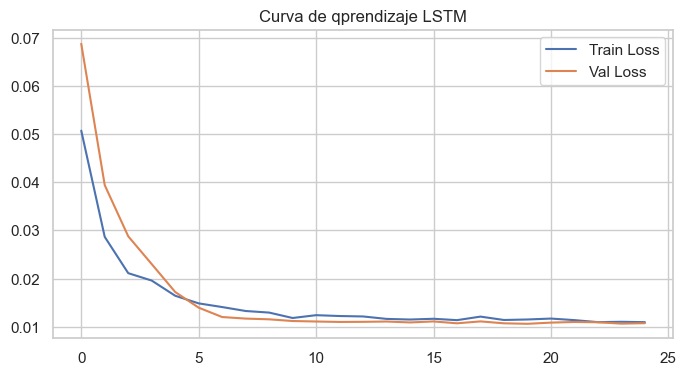

In [19]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Curva de qprendizaje LSTM')
plt.show()

In [20]:
#generacion de preds
pred_scaled = model.predict(X_test_lstm)

#desescalamiento
predicciones_lstm = scaler_y.inverse_transform(pred_scaled)

#trasnformar a arrays para calculo de metricas
real_array = y_test_raw.values.flatten()
pred_array = predicciones_lstm.flatten()

error = np.abs(real_array - pred_array)
wape_puro = (np.sum(np.abs(real_array - pred_array)) / np.sum(real_array)) * 100
diferencia_total_porcentual = ((pred_array.sum() - real_array.sum()) / real_array.sum()) * 100

print(f"Suma real total abril: {real_array.sum():,.2f}")
print(f"Suma pred total abril: {pred_array.sum():,.2f}")
print(f'Error acumulado abril: {error.sum():,.2f}')
print(f'Diff real: {real_array.sum() - pred_array.sum():,.2f}')
print(f"Diff total porcentual mensual: {diferencia_total_porcentual:.2f}%")
print(f"WMAPE total abril: {wape_puro:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Suma real total abril: 34,292,377.81
Suma pred total abril: 29,350,216.00
Error acumulado abril: 10,506,205.29
Diff real: 4,942,161.81
Diff total porcentual mensual: -14.41%
WMAPE total abril: 30.64%


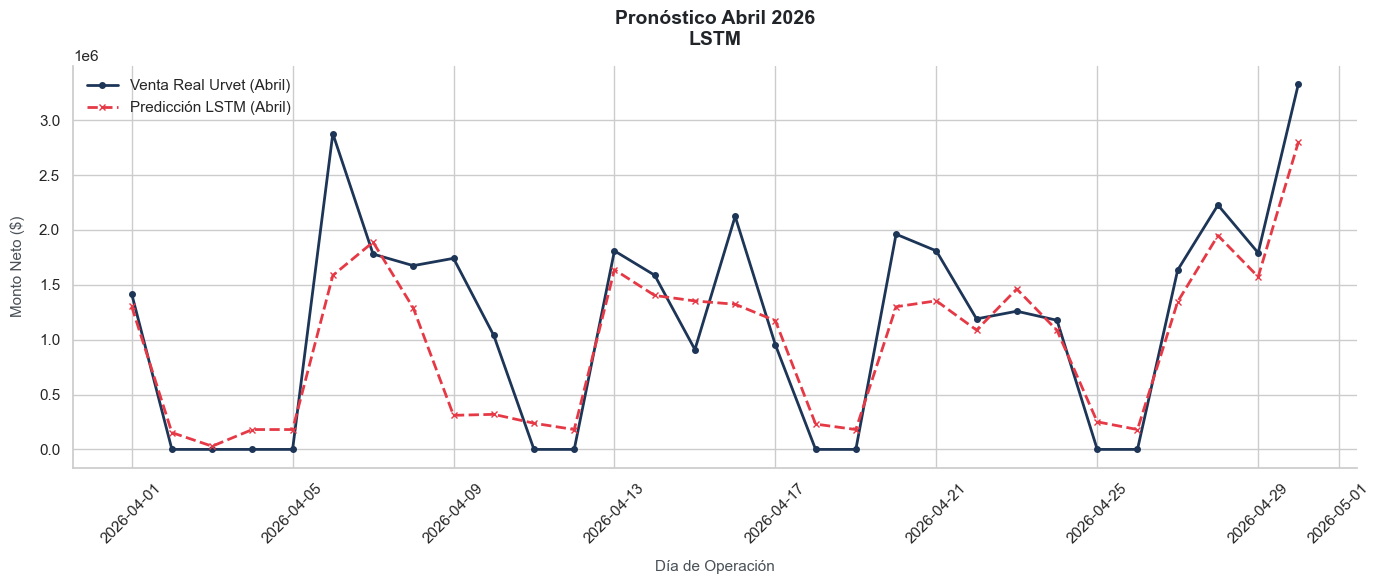

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6), dpi=100)

plt.plot(y_test_raw.index, real_array, marker='o', markersize=4, color='#1d3557', 
         linewidth=2, label='Venta Real Urvet (Abril)')
plt.plot(y_test_raw.index, pred_array, marker='x', markersize=4, color='#e63946', 
         linewidth=2, linestyle='--', label='Predicción LSTM (Abril)')

plt.title('Pronóstico Abril 2026\nLSTM', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Día de Operación', fontsize=11, labelpad=10, color='#495057')
plt.ylabel('Monto Neto ($)', fontsize=11, labelpad=10, color='#495057')

plt.xticks(rotation=45)
plt.legend(loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()